In [ ]:
import kagglehub
import os
import shutil

#Датасет про учеников и различные факторы. Целевая переменная - оценка за экзамен. В нем 6607 строк и 20 столбцов. 
cache_path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

csv_filename = [f for f in os.listdir(cache_path) if f.endswith('.csv')][0]
source_file = os.path.join(cache_path, csv_filename)

local_file_name = "data.csv"
shutil.copy(source_file, local_file_name)

'data.csv'

In [ ]:
from fontTools import subset
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv")

#Статистика
print(f"Размер датасета: {df.shape}\n")
display(df.head(3))
display(df.tail(3))

df.info()
display(df.describe())
display(df.describe(include="object"))
print(f"Дубликатов: {df.duplicated().sum()}")
print("Пропуски:")
display(df.isnull().sum()[df.isnull().sum() > 0])

#Пропуски и очистка

#Удаляем строки с пропусками, тк в зависимости от уровня образования родителей, может быть разное отношение к учебе в семье, следовательно, может быть разная успеваемость учеников.
df = df.dropna(subset=["Parental_Education_Level"])

#Тк расстояние до дома - это слово, то оцифруем этот столбец, а затем используем медиану (Можно сразу было использовать моду)
distance_mapping = {"Near": 1, "Moderate": 2, "Far": 3}
df["Distance_Numeric"] = df["Distance_from_Home"].map(distance_mapping)
median_distance = df['Distance_Numeric'].median()
df['Distance_Numeric'] = df['Distance_Numeric'].fillna(median_distance)
#Исходя из distance_numeric, заполняем пропуски в distance_from_home
distance_reverse_mapping = {1 : "Near", 2: "Moderate", 3: "Far"}
df["Distance_from_Home"] = df["Distance_Numeric"].map(distance_reverse_mapping)

#Teacher_Quality заполняем модой, тк лучше всего присвоить наиболее часто встречающееся значение
teacher_quality_mode = df["Teacher_Quality"].mode()[0]
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(teacher_quality_mode)

print("Пропуски:")
display(df.isnull().sum()[df.isnull().sum() > 0])




Размер датасета: (6607, 20)



,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


Дубликатов: 0
Пропуски:


Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Пропуски:


Series([], dtype: int64)

In [39]:
import pandas as pd

df = pd.read_csv("data.csv")

num_coloms = df.select_dtypes(include = ["int64", "float64"]).columns

print("Базовая cтатистика по числовым столбцам:")
print(f"    Min:\n{df[num_coloms].min()}")
print(f"    Max:\n{df[num_coloms].max()}")
print(f"    Mean:\n{df[num_coloms].mean()}")
print(f"    Median:\n{df[num_coloms].median()}")
print(f"    Mode:\n{df[num_coloms].mode().iloc[0]}") # 0 - тк медиан может быть несколько

print("\nПерцентили и кванитили")
display(df[num_coloms].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).T)

print("\nДисперсия, асимметрия и эксцесс")
print(f"    Дисперсия:\n{df[num_coloms].var()}") #Если у Exam_score дисперсия высокая, то это означает, что в классе есть круглые отличники и двоичники. Если дисперсия низкая, то большинство учеников имеют схожие оценки.
print(f"    Асимметрия:\n{df[num_coloms].skew()}") #Если у Exam_score асимметрия положительная, то в классе основная масса учеников - двоечники. Если отрицательная - отличники. Если близка у нулю,то в классе примерно одинаковое количество отличников и двоечников.
print(f"    Эксцесс:\n{df[num_coloms].kurt()}") #Если у Exam_score эксцесс положительный, то в классе многие написали на одинаковый балл, но есть 0 и 100. Если эксцесс близок к нулю, то оценки распределены предсказуемо, без резких пиков. Если эксцесс отрицательный, то оценки распределены равномерно (+- одинаковое количество каждой)
#Вывод: по Exam_score получается что в классе есть огромное количество человек которые написали на не очень хороший +- равный балл

Базовая cтатистика по числовым столбцам:
    Min:
Hours_Studied         1
Attendance           60
Sleep_Hours           4
Previous_Scores      50
Tutoring_Sessions     0
Physical_Activity     0
Exam_Score           55
dtype: int64
    Max:
Hours_Studied         44
Attendance           100
Sleep_Hours           10
Previous_Scores      100
Tutoring_Sessions      8
Physical_Activity      6
Exam_Score           101
dtype: int64
    Mean:
Hours_Studied        19.975329
Attendance           79.977448
Sleep_Hours           7.029060
Previous_Scores      75.070531
Tutoring_Sessions     1.493719
Physical_Activity     2.967610
Exam_Score           67.235659
dtype: float64
    Median:
Hours_Studied        20.0
Attendance           80.0
Sleep_Hours           7.0
Previous_Scores      75.0
Tutoring_Sessions     1.0
Physical_Activity     3.0
Exam_Score           67.0
dtype: float64
    Mode:
Hours_Studied        20
Attendance           67
Sleep_Hours           7
Previous_Scores      66
Tutoring_Sessio

,0.05,0.25,0.50,0.75,0.95
Hours_Studied,10.0,16.0,20.0,24.0,30.0
Attendance,62.0,70.0,80.0,90.0,98.0
Sleep_Hours,5.0,6.0,7.0,8.0,9.0
Previous_Scores,53.0,63.0,75.0,88.0,97.0
Tutoring_Sessions,0.0,1.0,1.0,2.0,4.0
Physical_Activity,1.0,2.0,3.0,4.0,5.0
Exam_Score,62.0,65.0,67.0,69.0,73.0



Дисперсия, асимметрия и эксцесс
    Дисперсия:
Hours_Studied         35.887221
Attendance           133.344178
Sleep_Hours            2.155377
Previous_Scores      207.353789
Tutoring_Sessions      1.514304
Physical_Activity      1.063438
Exam_Score            15.135646
dtype: float64
    Асимметрия:
Hours_Studied        0.013499
Attendance           0.013666
Sleep_Hours         -0.023805
Previous_Scores     -0.003737
Tutoring_Sessions    0.815530
Physical_Activity   -0.031365
Exam_Score           1.644808
dtype: float64
    Эксцесс:
Hours_Studied         0.017771
Attendance           -1.194407
Sleep_Hours          -0.503697
Previous_Scores      -1.191080
Tutoring_Sessions     0.643718
Physical_Activity    -0.059439
Exam_Score           10.575423
dtype: float64


In [ ]:
import category_encoders as ce
import pandas as pd

df = pd.read_csv("data.csv")

print("Датафрейм до")
display(df[['Hours_Studied', 'Exam_Score', 'Motivation_Level', 'Gender', 'Parental_Education_Level']].head(3))

#Feature Generation
df['Total_Academic_Effort'] = df['Hours_Studied'] + df['Tutoring_Sessions']
df['Score_per_Hour'] = df['Exam_Score'] / (df['Hours_Studied'] + 1)
df['Sleep_Category'] = df['Sleep_Hours'].apply(lambda x: 'Normal' if 7 <= x <= 9 else 'Innormal')


# LABEL ENCODING (С учетом иерархии)
mapping = {'Low': 0, 'Medium': 1, 'High': 2}

df['Motivation_Level_Encoded'] = df['Motivation_Level'].map(mapping)
df['Family_Income_Encoded'] = df['Family_Income'].map(mapping)

df = df.drop(columns=['Motivation_Level', 'Family_Income'])


# FEATURE HASHING 
hashing_enc = ce.HashingEncoder(cols=['Parental_Education_Level'], n_components=3)
df = hashing_enc.fit_transform(df)


# ONE-HOT ENCODING
# drop_first=True нужен, чтобы убрать лишнюю колонку (например, из Female/Male останется только одна колонка Male со значениями 1 и 0)
df = pd.get_dummies(df, columns=['Gender', 'School_Type', 'Sleep_Category'], drop_first=True)

print("\n Датафрейм после")
display(df.head(3))

Датафрейм до


,Hours_Studied,Exam_Score,Motivation_Level,Gender,Parental_Education_Level
0,23,67,Low,Male,High School
1,19,61,Low,Female,College
2,24,74,Medium,Male,Postgraduate



 Датафрейм после


,col_0,col_1,col_2,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,...,Learning_Disabilities,Distance_from_Home,Exam_Score,Total_Academic_Effort,Score_per_Hour,Motivation_Level_Encoded,Family_Income_Encoded,Gender_Male,School_Type_Public,Sleep_Category_Normal
0,1,0,0,23,84,Low,High,No,7,73,...,No,Near,67,23,2.791667,0,0,True,True,True
1,1,0,0,19,64,Low,Medium,No,8,59,...,No,Moderate,61,21,3.050000,0,1,False,True,True
2,0,0,1,24,98,Medium,Medium,Yes,7,91,...,No,Near,74,26,2.960000,1,1,True,True,True


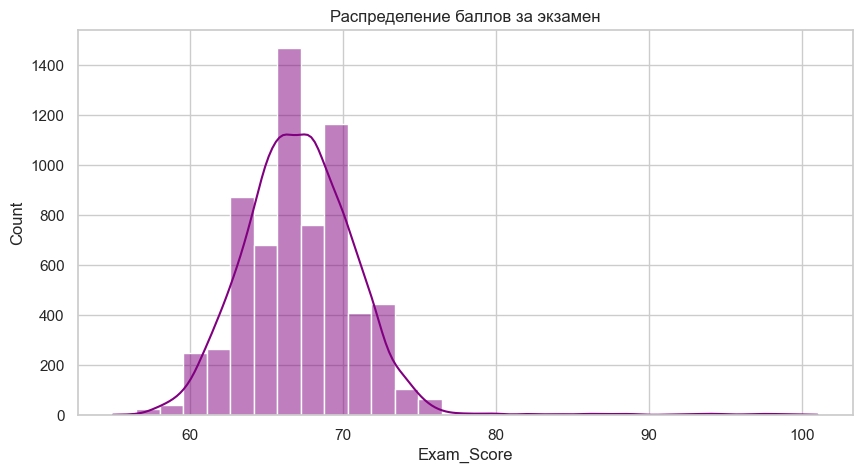

C:\Users\acizi\AppData\Local\Temp\ipykernel_48560\3749548220.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Exam_Score', data=df, palette='Set2')


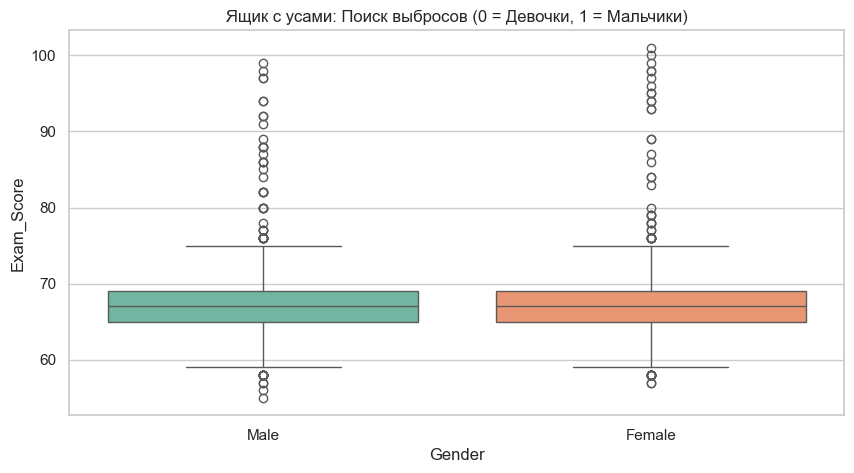

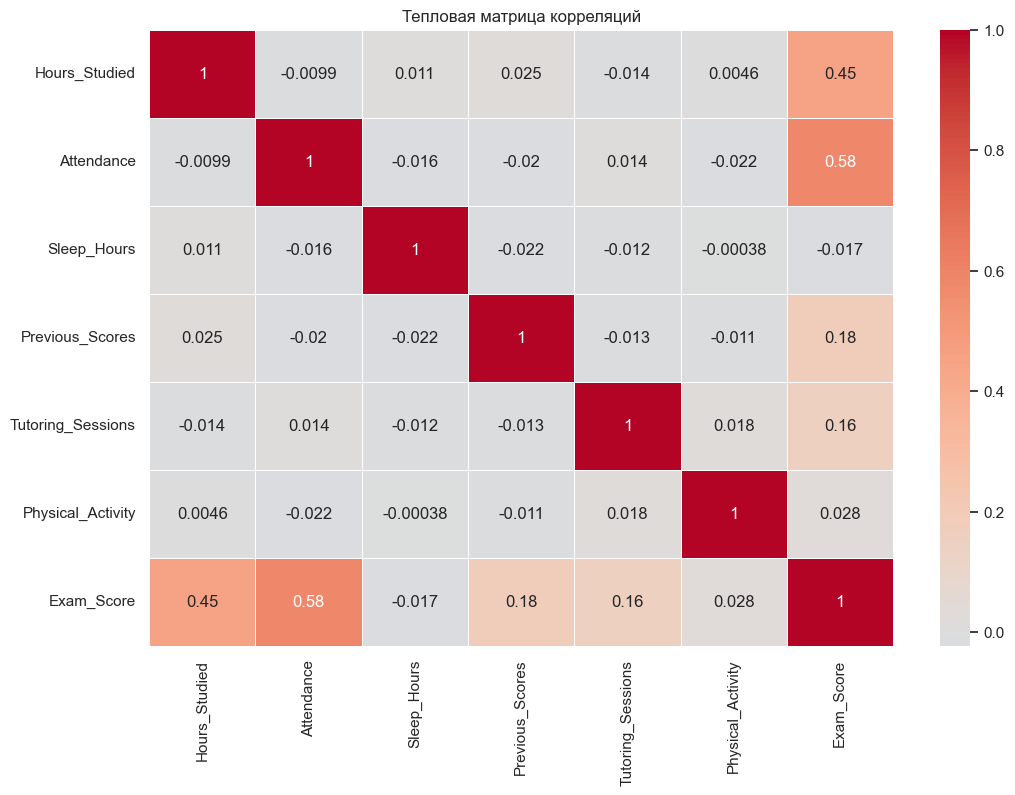

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("data.csv")

sns.set_theme(style="whitegrid")

# 1. Гистограмма баллов
plt.figure(figsize=(10, 5))
sns.histplot(df['Exam_Score'], kde=True, bins=30, color='purple')
plt.title('Распределение баллов за экзамен')
plt.show()

# 2. Box Plot аномалий
plt.figure(figsize=(10, 5))
sns.boxplot(x='Gender', y='Exam_Score', data=df, palette='Set2')
plt.title('Ящик с усами: Поиск выбросов (0 = Девочки, 1 = Мальчики)')
plt.show()

# 3. Тепловая карта корреляций
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Тепловая матрица корреляций')
plt.show()

# 4. Интерактивный Scatter Plot (Plotly)
fig = px.scatter(df, 
                 x='Hours_Studied', 
                 y='Exam_Score', 
                 hover_data=['Attendance', 'Sleep_Hours', 'School_Type', 'Teacher_Quality'],
                 color='Motivation_Level',
                 title='Интерактивный Scatter Plot: Учеба vs Оценки',
                 opacity=0.7)
fig.show()

   
1 Данные про студентов
2 В датасете были пропуски, которые были утсранены.
3 Целевая переменная - Exam_score
4 Исходя из асимметрии, эксцесса и дисперсии, ученики сдали экзамен примено равные плохие баллы
5 Самая большая дисперсия у Previous_Scores
6 Категориальные признаки требуют разного подхода: для номинальных (Gender, School_Type) отлично подходит One-Hot Encoding.    Для ординальных признаков (Motivation_Level) - Label Encoding для сохранения математической иерархии (Low < Medium < High)
7 Метод Feature Hashing хорош как инструмент снижения размерности при кодировании текста, что будет полезно на более крупных рабочих датасетах


 




1 Выбросы в Exam_Score появляются из-за учеников, которые много учатся
2 Часы учебы и общая посещаемость являются ключевыми аспектами роста итогового балла
3 Здровый сон, тип школы и качество учителя не гарантируют хороший балл

1 Из-за выбросов использовал бы Random Forest Regressor

1 Просил составить план на каждый пункт; спрашивал ошибки; просил объяснить дисперсию , асимметрию  и эксцесс на примере данных датасета.
2 Просил сгенерировать код, который затем разбирал, а потом осмысленно реализовал